# TP Science des données

# Importation des librairies

In [3]:
import numpy as np
import pandas as pd
import sklearn 

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.ensemble import IsolationForest
from sklearn import neighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.covariance import LedoitWolf

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from pylab import rcParams

# Génération de données

In [6]:
X , y = sklearn.datasets.make_circles(n_samples= 400, noise= 0.1, factor= 0.3)

In [7]:
#  Ajout des points abberants

x_dirty = np.array([[24.9, 0.1],
                    [23, 1],
                    [24.8, 0.6],
                    [27, 0.1]])

# Ajout aux données
X_dirty= np.append(X, x_dirty, axis=0)
y_dirty = np.append(y , [1, 1, 1, 1], axis=0)

In [8]:
X_dirty
y_dirty

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,

In [9]:
## Create a dataframe

df = pd.DataFrame(dict(x=X_dirty[:,0] , y=X_dirty[:,1], label= 1 - y_dirty))
print(df.columns[0])
colors = {0 : 'red', 1:'blue'}
df_grouped = df.groupby('label')

x


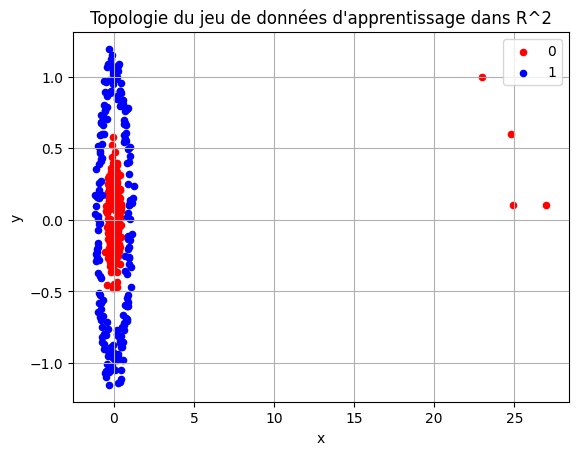

In [10]:
# Graphique 
fig , ax = plt.subplots()
for key, group in df_grouped:
    group.plot(ax=ax , kind = 'scatter', x='x', y='y', label=key, color=colors[key])

plt.grid()
plt.title("Topologie du jeu de données d'apprentissage dans R^2")
plt.show()


Ce qu'on remarque c'est la forte densité de probabilité sur la droite d'équation : y = 0  , que la densité de probabilité est très forte pour les éléments de la classe 0.

(à appronfondir)

# Modèles génératifs QDA et effondrement paramétrique

In [11]:
## Entrainement des données
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# On crée nos datasets de train et de test. => On prend 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X_dirty, y_dirty, test_size=0.2, random_state=42)

# Analyse quadratique discriminante
qda_clf = QuadraticDiscriminantAnalysis()

qda_clf.fit(X_train, y_train)


,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


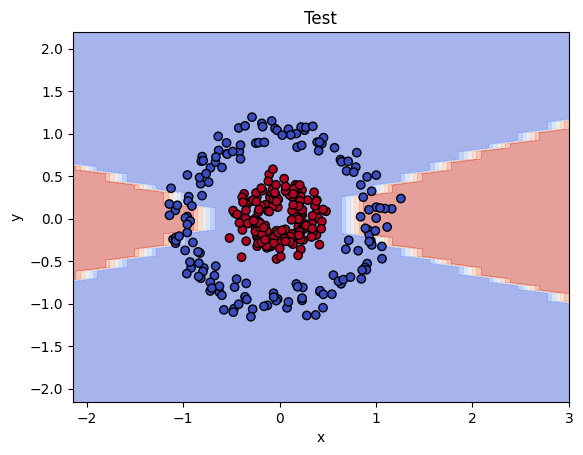

In [12]:
# Plotting the boundaries
disp = DecisionBoundaryDisplay.from_estimator(qda_clf, 
                                              X_train, 
                                              response_method="predict",
                                              xlabel=df.columns[0], ylabel=df.columns[1],
                                              alpha=0.5, 
                                              cmap=plt.cm.coolwarm)
# Plotting the data points    
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], 
                 c=y_train, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.title("Test")
plt.xlim(right=3)
plt.show()

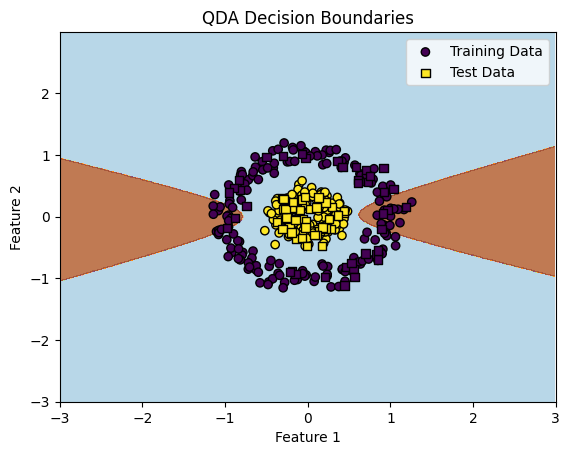

In [13]:
# Create a mesh to plot the decision boundaries
x_min, x_max = (-3 , 3)
y_min, y_max = (-3, 3)
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict class using the classifier for each point in the mesh
Z = qda_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', marker='o', label='Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', marker='s', label='Test Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(right=3)
plt.title('QDA Decision Boundaries')
plt.legend()
plt.show()

Le fait qu'il y ait des outliers pour la classe 0 biaise totalement notre séparateur qui nous renvoit des frontières sorties du chapeau ...

La formule de la distance de Mahalanobis : $$ D_{M}=\sqrt{(X - \mu)^T\hat{\Sigma}^{-1}(X - \mu)} $$

D'après la formule de la covariance : $$ \hat{\Sigma} = 1/(N_{k} - 1) \sum (X - \hat{\mu}_{k}) (X - \hat{\mu}_{k})^{T} $$

On remarque que les espérances font parties de du calcul de la distance de Mahalanobis et que l'espérance est très sensible aux valeurs extrêmes (les outliers) , c'est pourquoi, une fois le calcul des frontières, il y a des petits problèmes ...

## Analyse LSA

L'analyse discriminante linéaire (LSA) n'est pas adaptée car les données ne peuvent être séparées linéairement quand bien même il n'y aurait pas d'outliers.

## Utilisation IsolationForest

Isolation Forest est l'un des algorithmes les plus populaires dans la detection d'anomalie , on parle de 'foret' car chaque élément du dataset se voit appliquer des décisions si oui ou non il est catégoriser outlier. 
Complexité linéaire, très bien 

In [14]:
#Paramètres par défault trouvé sur notebook 
Iforest = IsolationForest(max_samples=100, 
                          random_state=1111,
                         contamination=0.05,
                         max_features=1.0,
                         n_estimators=100,
                         verbose=1,
                         n_jobs=-1)
Iforest.fit(X_dirty)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",100
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1111
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",1
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [15]:
predictions_outliers= Iforest.predict(X_dirty)

#print(predictions_outliers)
predi_adjusted = [1 if x == -1 else 0 for x in predictions_outliers]
condition_true = np.array(predi_adjusted) == 0
print(condition_true)
X_cleaned = np.array(X_dirty)[condition_true]
y_cleaned = np.array(y_dirty)[condition_true]

[ True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True  True  True  True  T

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [16]:
X_cleaned
y_cleaned


array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,

In [17]:
## Create a dataframe cleaned

df_cleaned = pd.DataFrame(dict(x=X_cleaned[:,0] , y=X_cleaned[:,1], label= 1 - y_cleaned))
colors = {0 : 'red', 1:'blue'}
df_grouped_cleaned = df_cleaned.groupby('label')



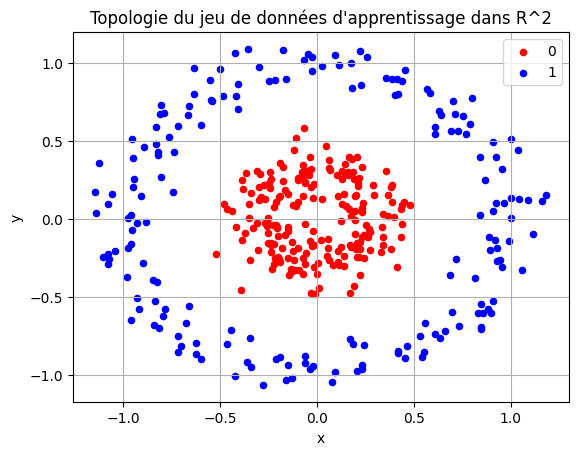

In [18]:
# Graphique 
fig , ax = plt.subplots()
for key, group in df_grouped_cleaned:
    group.plot(ax=ax , kind = 'scatter', x='x', y='y', label=key, color=colors[key])

plt.grid()
plt.title("Topologie du jeu de données d'apprentissage dans R^2")
plt.show()

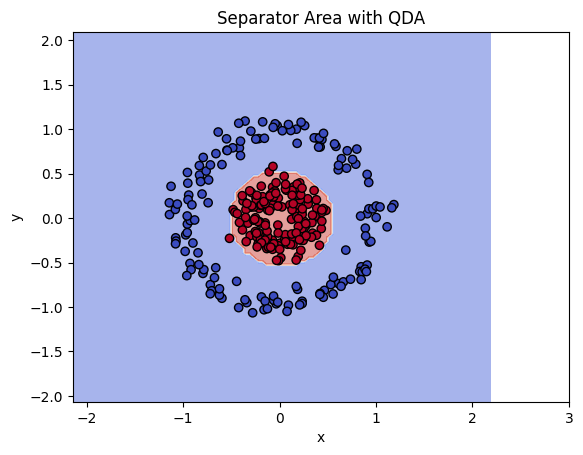

In [19]:
## Entrainement des données
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# On crée nos datasets de train et de test. => On prend 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Analyse quadratique discriminante
qda_clf_cleaned = QuadraticDiscriminantAnalysis()

qda_clf_cleaned.fit(X_train, y_train)

# Plotting the boundaries
disp = DecisionBoundaryDisplay.from_estimator(qda_clf_cleaned, 
                                              X_train, 
                                              response_method="predict",
                                              xlabel=df_cleaned.columns[0], ylabel=df_cleaned.columns[1],
                                              alpha=0.5, 
                                              cmap=plt.cm.coolwarm)
# Plotting the data points    
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], 
                 c=y_train, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.title("Separator Area with QDA")
plt.xlim(right=3)
plt.show()

## K - NN , Topologie locale

In [20]:
def classify_and_plot(X, y):
    ''' 
    split data, fit, classify, plot and evaluate results 
    '''
    # split data into training and testing set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 41)

    # init vars
    n_neighbors = 5
    h           = .02  # step size in the mesh

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])

    rcParams['figure.figsize'] = 5, 5
    for weights in ['uniform', 'distance']:
        # we create an instance of Neighbours Classifier and fit the data.
        clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
        clf.fit(X_train, y_train)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)
        fig = plt.figure()
        plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

        # Plot also the training points, x-axis = 'Glucose', y-axis = "BMI"
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)   
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.title("0/1 outcome classification (k = %i, weights = '%s')" % (n_neighbors, weights))
        plt.show()

        # evaluate
        y_expected  = y_test
        y_predicted = clf.predict(X_test)

        # print results
        print('----------------------------------------------------------------------')
        print('Classification report')
        print('----------------------------------------------------------------------')
        print('\n', classification_report(y_expected, y_predicted))


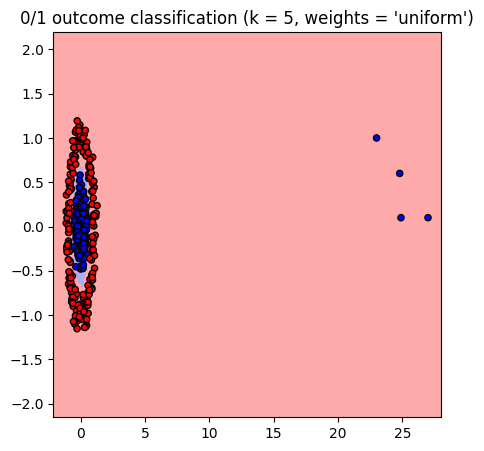

----------------------------------------------------------------------
Classification report
----------------------------------------------------------------------

               precision    recall  f1-score   support

           0       0.97      1.00      0.98        61
           1       1.00      0.97      0.99        73

    accuracy                           0.99       134
   macro avg       0.98      0.99      0.98       134
weighted avg       0.99      0.99      0.99       134



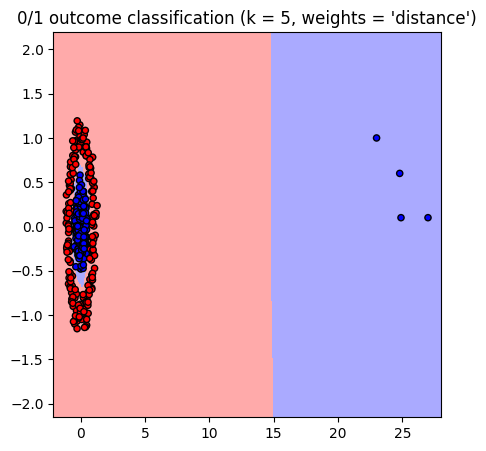

----------------------------------------------------------------------
Classification report
----------------------------------------------------------------------

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        73

    accuracy                           1.00       134
   macro avg       1.00      1.00      1.00       134
weighted avg       1.00      1.00      1.00       134



In [21]:
classify_and_plot(X_dirty, y_dirty)

Le code que j'ai récupéré ici : 'https://stackoverflow.com/questions/56153726/plot-k-nearest-neighbor-graph-with-8-features' utilise les deux manières de calculer les poids suivant la distance ou de manière uniforme.

On remarque que le KNN ne subit pas la même déformation que QDA malgré les outliers dans la région [-3, 3]
On se place dans le plan affine $$ R^{2} $$

 "Soit S un ensemble fini de n points du plan ; les éléments de S sont appelés centres, sites ou encore germes. On appelle région de Voronoï — ou cellule de Voronoï — associée à un germe p de S, l’ensemble des points qui sont plus proches de p que de tout autre point de S" (Source wikipédia). 
Ainsi les cellules de Voronoï des outiliers vont n'avoir aucune influence localement sur notre région [-3 , 3] car bloquée par la zone d'influence des autres éléments ayant le label 1

### Approche MinMaxScaler

In [23]:
## Pipeline d'étapes
pipeline= Pipeline([ ('scaler', MinMaxScaler()),('knn',neighbors.KNeighborsClassifier(n_neighbors=5))])

pipeline.fit(X_dirty, y_dirty)

scaler = pipeline.named_steps['scaler']
knn = pipeline.named_steps['knn']

X_dirty_scaled = scaler.transform(X_dirty)

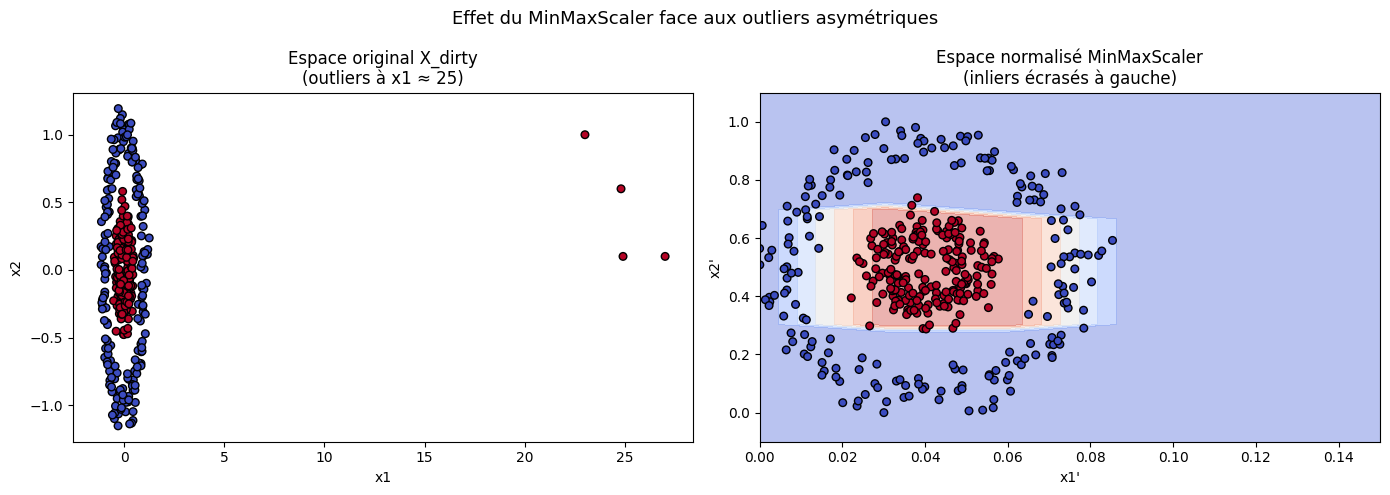

In [ ]:
# Figure et axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = DecisionBoundaryDisplay.from_estimator(knn,X_dirty_scaled,
    response_method='predict',
    alpha=0.4,
    cmap=plt.cm.coolwarm,
    ax=axes[1]
)

# Graphique
axes[0].scatter(X_dirty[:, 0], X_dirty[:, 1],c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k', s=30)
axes[0].set_title("Espace original X_dirty")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")

disp.ax_.scatter(X_dirty_scaled[:, 0], X_dirty_scaled[:, 1],
                 c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k', s=30)

axes[1].set_xlim(0, 0.15)
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_title("Espace normalisé avec MinMaxScaler")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")

plt.suptitle("Effet du MinMaxScaler face aux outliers asymétriques", fontsize=13)
plt.tight_layout()
plt.show()

Formule du MinMaxScaler : 

$$ x_{scaled} = (x - x_{min})\x_{max} - x_{min}) $$

Les outliers avec des valeurs abberantes sur x1 "rétrécissent" encore plus les données ce qui fait que la distance entre les points est plus faible.

On remarque bien les zones d'influences qui ne sont plus des cercles mais dont les carrés/rectangles (bandes étirées). 
- J'ai remarqué que la distance euclienne ressemblait très franchement à la formule du rayon d'un cercle.

$$ r = \sqrt{x^2 + y^2}. $$. 
Je me suis dit qu'il y avait un lien du fait que d'une zone d'influence en cercle, on passe à une zone d'influence en bandes étirées. 
Comme on normalise avec MinMaxScaler, on vient changer nos valeurs de x et de y en : $$ x^{'} = \frac{x}{a} y^{'} = \frac{y}{b}$$. 

On a donc après normalisation la formule du rayon d'une ellipse , ce qui n'est plus une distance euclidienne standar mais une **distance elliptique** => bandes horizontales du KNN.

### RobustScaler

In [30]:
## Pipeline d'étapes
pipeline= Pipeline([ ('scaler', RobustScaler()),('knn',neighbors.KNeighborsClassifier(n_neighbors=5))])

pipeline.fit(X_dirty, y_dirty)

scaler = pipeline.named_steps['scaler']
knn = pipeline.named_steps['knn']

X_dirty_scaled = scaler.transform(X_dirty)

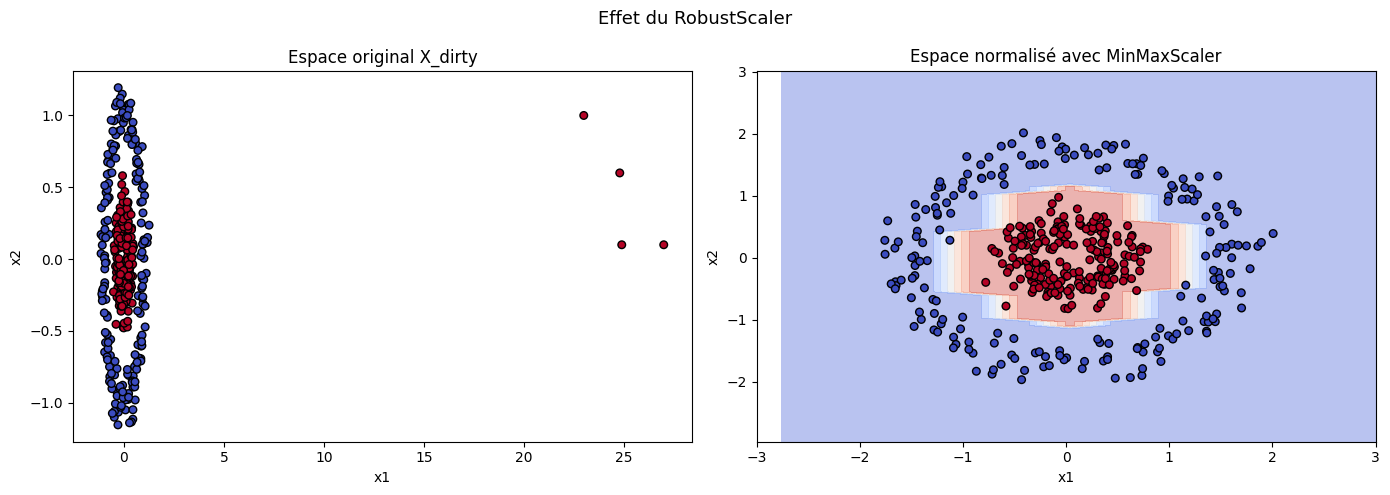

In [ ]:
# Figure et axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = DecisionBoundaryDisplay.from_estimator(knn,X_dirty_scaled,
    response_method='predict',
    alpha=0.4,
    cmap=plt.cm.coolwarm,
    ax=axes[1]
)

# Graphique
axes[0].scatter(X_dirty[:, 0], X_dirty[:, 1],c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k', s=30)
axes[0].set_title("Espace original X_dirty")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")

disp.ax_.scatter(X_dirty_scaled[:, 0], X_dirty_scaled[:, 1],
                 c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k', s=30)

axes[1].set_xlim(-3, 3)
#axes[1].set_ylim(-, 1.1)
axes[1].set_title("Espace normalisé avec RobustScaler")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")

plt.suptitle("Effet du RobustScaler", fontsize=13)
plt.tight_layout()
plt.show()

On remarque que la frontière est revenue (à peu près) à une frontière en cercle. 
L'effet du RobustScaler : $ x_{scale} = \frac{x - x_{median}}{IQR}$. 
Ce qui a pour effet de garder les dénominateurs stables (on a plus de valeurs très grandes) ce qui dans la formule de la distance euclienne se rapproche bien de celle du rayon d'un cercle et non plus de celle d'une ellipse.

## SVM , astuce du noyau et marge souple.

Le noyau $$ K(x,z) = (<x,z> +1)^{2}$$. 
Se développe par :  
$$ (<x,z>^{2} +2<x,z> +1)$$. 
Avec $$ <x,z> = x1.z1 + x2.z2 pour x = (x_{1}, x_{2}) et z = (z_{1}, z_{2}) $$. 
Soit :
$$ (x_{1}.z_{1})^{2} + 2(x_{1}.z_{1})(x_{2}.z_{2}) + (x_{2}.z_{2})^{2} + 2(x_{1}.z_{1}+ x_{2}.z_{2}) +1 $$. 
Ce qui nous donne le produit scalaire en dimension 6 de deux nouveux vecteurs  :$$ K(x,z) = (x_{1}^{2}, x_{2}^{2}, \sqrt{2x_{1}x_{2}}, \sqrt{2x_{1}}, \sqrt{2x_{2}}, 1 )^{T} (z_{1}^{2}, z_{2}^{2}, \sqrt{2z_{1}z_{2}}, \sqrt{2z_{1}}, \sqrt{2z_{2}}, 1 ) $$.



Soit un séparateur linéaire du vecteur $ \phi $: $$ W^{T}\phi + b = 0 $$.

Ce noyeau permet de séparer linéairement dans l'espace de redescription $ \phi(x) $. 




### Graphiques

In [67]:
pipeline = Pipeline([('scaler', RobustScaler()), ('svm', SVC(kernel='poly', degree=2, coef0=1.0, C=100000, max_iter=10000))])

pipeline.fit(X_dirty, y_dirty)

svm = pipeline.named_steps['svm']
scaler = pipeline.named_steps['scaler']

/Users/florentsaunier/Documents/Documents - MacBook Pro de Florent/GEM_big_data/Statistic-learning-project/env/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


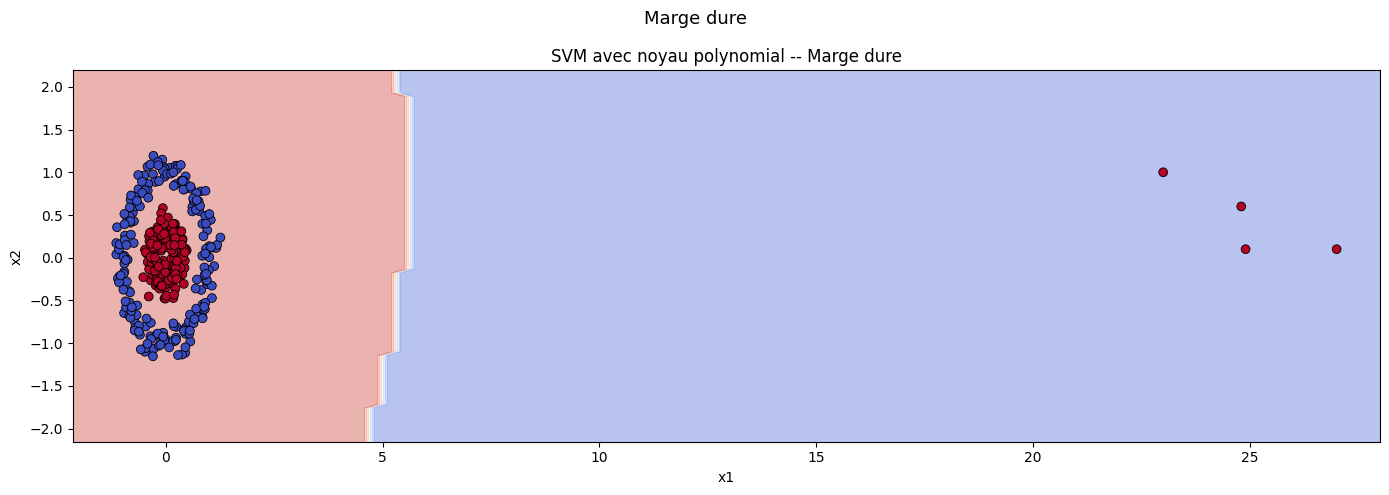

In [68]:
# Graphiques
# Figure et axes
fig, axe = plt.subplots(figsize=(14, 5))

disp = DecisionBoundaryDisplay.from_estimator(svm,X_dirty,
    response_method='predict',
    alpha=0.4,
    cmap=plt.cm.coolwarm,
    ax=axe
)

disp.ax_.scatter(X_dirty[:, 0], X_dirty[:, 1],
                 c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k',linewidths=0.6, s=40, zorder=3)

#axe.set_xlim(-3, 3); axe.set_ylim(-3, 3)
axe.set_title("SVM avec noyau polynomial -- Marge dure")
axe.set_xlabel("x1"); axe.set_ylabel("x2")

plt.suptitle("Marge dure", fontsize=13)
plt.tight_layout()
plt.show()

In [69]:
pipeline = Pipeline([('scaler', RobustScaler()), ('svm', SVC(kernel='poly', degree=2, coef0=1.0, C=0.05, max_iter=10000))])

pipeline.fit(X_dirty, y_dirty)

svm = pipeline.named_steps['svm']
scaler = pipeline.named_steps['scaler']

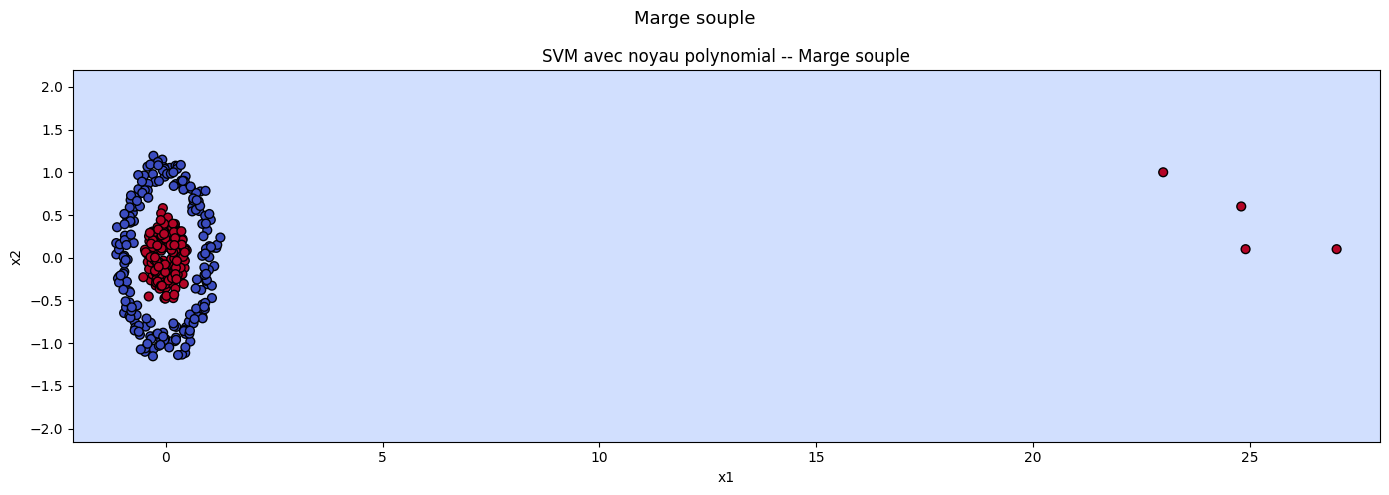

In [70]:
# Graphiques
# Figure et axes
fig, axe = plt.subplots(figsize=(14, 5))

disp = DecisionBoundaryDisplay.from_estimator(svm,X_dirty,
    response_method='predict',
    alpha=0.4,
    cmap=plt.cm.coolwarm,
    ax=axe
)

disp.ax_.scatter(X_dirty[:, 0], X_dirty[:, 1],
                 c=y_dirty, cmap=plt.cm.coolwarm, edgecolor='k', s=40)

#axe.set_xlim(-3, 3); axe.set_ylim(-3, 3)
axe.set_title("SVM avec noyau polynomial -- Marge souple")
axe.set_xlabel("x1"); axe.set_ylabel("x2")

plt.suptitle("Marge souple", fontsize=13)
plt.tight_layout()
plt.show()

Plus C est élevé (Marge dure) plus la pénalité est forte (cf primal) ce qui va tordre la frontière quand il y a des outliers. 
Si C est très faible, les xi permettent de savoir où se situent les points. 
- Si $ \xi  = 0 $ , cela signifie que le point est bien classé , derrière sa frontière. 
- Si  $ 0 < \xi ≤ 1 $ , le point est dans l'espace de marge mais pas derrière sa frontière. 
- Si $ \xi > 1 $ , le point est en dehors de l'espace de marche, il est mal classé.

!['test'](images/marge_distance_xi.png)


## Fléau de la grande dimension

In [51]:
# Création de la matrice

X = np.random.randn(50, 200)

sigma_chapeau = np.cov(X , rowvar=False)

rang = np.linalg.matrix_rank(sigma_chapeau)

print(f"Le range de cette matrice est : {rang} ")

Le range de cette matrice est : 49 


On prend l'expression : $$ max[rang(\frac{1}{n-1}X_{c}^TX_{c})]$$. 

Qui peut se majorer par : $ max(rang(\frac{1}{n-1}X_{c}^TX_{c}))≤ max(min(rang(X_{c}^T), rang(X_{c}))) $. 

Ce qui nous donne 49 car on est centré autour de 0 pour la loi normale. (On perd un degré de liberté). 

Impossibilité à inverser $ \hat{\Sigma}^T $ car il y a 200 - 49 = 151 valeurs propres nulles

QDA a besoin de $ (\hat{\Sigma}^{T})^{-1} $ ce qui n'est pas possible mathématiquement , informatiquement , les valeurs propres valent quelque chose donc on peut quand même avoir un résultat mais qui sera mauvais.

In [64]:
# Calcul des valeurs propres

valeurs_propres, vecteur = np.linalg.eigh(sigma_chapeau)

valeurs_nulles = 0

for vp in valeurs_propres:
    if vp < 1e-10:
        valeurs_nulles+= 1

print(f"Il y a {valeurs_nulles} valeurs propres qui sont égales à 0")    


Il y a 151 valeurs propres qui sont égales à 0


In [66]:
# régularisation

lw = LedoitWolf()
lw.fit(X)

Sigma_LW = lw.covariance_   # shape : (200, 200)
alpha_lw  = lw.shrinkage_

rang_LW = np.linalg.matrix_rank(Sigma_LW)
vp_LW, _ = np.linalg.eigh(Sigma_LW)

print(f"Le rang de la matrice est maintenant de : {rang_LW}")

Le rang de la matrice est maintenant de : 200


### Théorie derrière Shrinkage de Ledoit-wolf

J'ai l'impression que ça part du théorème spectrale qui garantit qu'une matrice A semi-définie positive peut être diagonalisée à l'aide d'une matrice de changement de base orthogonale : $$ A = GDG^{T} $$. 

Avec D = diag($\lambda_{1}$, ... $\lambda_{n}$)

Donc d'après l'expression : $$ \hat{\Sigma}_{LW} = (1 - \alpha)\hat{\Sigma} + \alpha\frac{Tr(\hat{\Sigma_{LW}})}{p}I_{p} $$

$ \hat{\Sigma}$ étant semi-définie positive et $ I_{p} = GG^{T} on peut écire :

$$ \hat{\Sigma}_{LW} = (1 - \alpha)GDG^{T} + \alpha\frac{Tr(\hat{\Sigma_{LW}})}{p}GG^{T} $$

En factorisant : $$ \hat{\Sigma}_{LW} = G[(1 - \alpha)D + \alpha\frac{Tr(\hat{\Sigma_{LW}})}{p}]G^{T} $$. 

Ce qui nous donne $ D = (1 - \alpha)D + \alpha\frac{Tr(\hat{\Sigma_{LW}})}{p} $ qui contient les nouvelles valeurs propres avec $ \forall i \in {1,2 , .... p} $ et surtout qui dépend de p , donc notre rang est de p.